<a href="https://colab.research.google.com/github/Alinberlian/iris-bootstrap-eda/blob/main/Data_Pre_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Berlian Mumtajmia L
2304010027

#Tugas Pre-Processing Data: Analisis Penjualan Mobil Historis

Konteks Data
Dataset ini (historical_automobile_sales.csv) berisi rekaman historis penjualan mobil di berbagai kota beserta faktor-faktor makroekonomi yang mempengaruhinya dari tahun 1980 hingga 2023.

Tujuan Analisis: Memahami variabel apa saja yang berdampak pada volume penjualan mobil (Automobile_Sales).

Karakteristik Data: Memiliki 528 observasi dan 15 variabel yang terdiri dari data runtun waktu (Date, Year, Month), indikator makroekonomi (GDP, Unemployment Rate, Consumer Confidence, Recession), serta data pasar (Price, Advertising Expenditure, Competition).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#1. Load Dataset

In [5]:
df = pd.read_csv('historical_automobile_sales.csv')

display(df.head())

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


#2. Data Wrangling (Inspeksi dan Pembersihan Awal)

tahap pertama adalah memahami tipe data dan mendeteksi adanya anomali atau missing values.

In [6]:
print("--- Info Dataset ---")
df.info()

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

# Mengubah tipe data 'Date' menjadi format Datetime yang standar
df['Date'] = pd.to_datetime(df['Date'])
print("\n[TINDAKAN] Kolom 'Date' berhasil diubah ke format Datetime.")

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    object 
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    object 
 3   Recession                528 non-null    int64  
 4   Consumer_Confidence      528 non-null    float64
 5   Seasonality_Weight       528 non-null    float64
 6   Price                    528 non-null    float64
 7   Advertising_Expenditure  528 non-null    int64  
 8   Competition              528 non-null    int64  
 9   GDP                      528 non-null    float64
 10  Growth_Rate              528 non-null    float64
 11  unemployment_rate        528 non-null    float64
 12  Automobile_Sales         528 non-null    float64
 13  Vehicle_Type             528 non-null    object 
 14  City 

Kita akan mengecek apakah ada data yang kosong (Null/NaN) dan memastikan tipe datanya sudah benar. Kolom Date masih berupa object (teks), nanti akan kita ubah formatnya.

# Boxplot

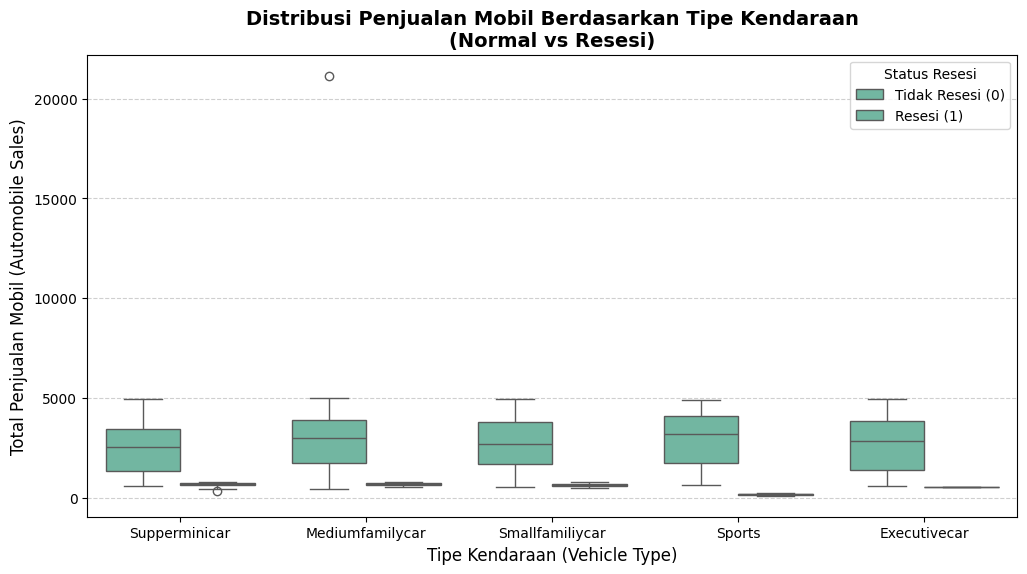

In [11]:
# Mengatur ukuran kanvas grafik
plt.figure(figsize=(12, 6))

# Membuat Boxplot
# x = Kategori Tipe Kendaraan, y = Target Penjualan
# hue = Memisahkan box berdasarkan status Resesi
sns.boxplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession',
            palette=['#66c2a5', '#fc8d62'])

# Menambahkan judul dan label
plt.title('Distribusi Penjualan Mobil Berdasarkan Tipe Kendaraan\n(Normal vs Resesi)', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Kendaraan (Vehicle Type)', fontsize=12)
plt.ylabel('Total Penjualan Mobil (Automobile Sales)', fontsize=12)

# Menambahkan grid pada sumbu Y agar nilai lebih mudah dibaca
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

# Mempercantik legenda
plt.legend(title='Status Resesi', labels=['Tidak Resesi (0)', 'Resesi (1)'])

# Menampilkan grafik
plt.show()

Efek Resesi yang Nyata: Perhatikan bahwa di hampir semua tipe kendaraan, kotak berwarna oranye (saat Resesi) posisinya jauh lebih rendah dan lebih gepeng (pendek) dibandingkan kotak hijau (saat Normal). Ini menandakan median penjualan menurun drastis dan variasinya menyempit saat ekonomi memburuk.

Perbedaan Preferensi: Mobil tipe Mediumfamilycar dan Smallfamiliycar memiliki volume penjualan tertinggi (posisi kotaknya paling atas) saat kondisi normal. Namun, saat terjadi resesi, hampir semua tipe mobil penjualannya anjlok ke angka yang mirip.

Deteksi Outlier Visual: Perhatikan titik-titik (lingkaran kecil) yang berada di luar garis batas atas pada boxplot (terutama pada Supperminicar). Titik-titik inilah yang sebelumnya kita deteksi secara matematis menggunakan perhitungan IQR, dan mengonfirmasi alasan mengapa kita butuh melakukan Tahap Capping Outlier di langkah selanjutnya!

# 3. Penanganan Pencilan (Outlier Treatment)

Sesuai kaidah pembersihan data statistik, keberadaan outlier dapat mendistorsi model analisis. Berdasarkan pengecekan awal, terdapat outlier pada variabel unemployment_rate, Growth_Rate, Price, Consumer_Confidence, dan Automobile_Sales.

In [7]:
# Membuat salinan data agar data asli tetap utuh
df_processed = df.copy()

# Daftar kolom numerik yang terdeteksi memiliki outlier
outlier_cols = ['unemployment_rate', 'Growth_Rate', 'Price', 'Consumer_Confidence', 'Automobile_Sales']

print("--- Proses Capping Outlier dengan Metode IQR ---\n")

for col in outlier_cols:
    # Menghitung Q1 (Kuartil 1) dan Q3 (Kuartil 3)
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)

    # Menghitung selisih IQR
    IQR = Q3 - Q1

    # Menentukan batas bawah dan batas atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mengganti (capping) nilai yang melebihi batas dengan nilai batas itu sendiri
    df_processed[col] = np.where(df_processed[col] > upper_bound, upper_bound,
                        np.where(df_processed[col] < lower_bound, lower_bound, df_processed[col]))

    print(f"[SELESAI] Outlier pada '{col}' telah disesuaikan ke rentang batas [{lower_bound:.2f}, {upper_bound:.2f}].")

# Mengecek kembali outlier pada salah satu kolom ekstrem (misal unemployment_rate) untuk konfirmasi
print("\n--- Cek Maksimum Tingkat Pengangguran Setelah Capping ---")
print(f"Max Unemployment Rate: {df_processed['unemployment_rate'].max():.2f}")

--- Proses Capping Outlier dengan Metode IQR ---

[SELESAI] Outlier pada 'unemployment_rate' telah disesuaikan ke rentang batas [-0.35, 4.85].
[SELESAI] Outlier pada 'Growth_Rate' telah disesuaikan ke rentang batas [-2.02, 1.83].
[SELESAI] Outlier pada 'Price' telah disesuaikan ke rentang batas [11435.72, 38149.26].
[SELESAI] Outlier pada 'Consumer_Confidence' telah disesuaikan ke rentang batas [72.73, 129.55].
[SELESAI] Outlier pada 'Automobile_Sales' telah disesuaikan ke rentang batas [-3437.33, 7846.08].

--- Cek Maksimum Tingkat Pengangguran Setelah Capping ---
Max Unemployment Rate: 4.85


Karena outlier pada data makroekonomi biasanya mewakili kejadian nyata (misal: lonjakan pengangguran saat resesi), kita tidak membuang baris datanya (dropping). Kita menggunakan metode Capping (Winsorization) berbasis nilai Interquartile Range (IQR). Nilai ekstrem yang melebihi batas bawah atau batas atas akan "dipotong" dan diganti dengan nilai batas maksimum/minimum IQR tersebut.

# 4. Feature Engineering pada Data Numerik (Scaling)

Variabel numerik dalam data ini memiliki skala yang sangat berbeda. Contohnya, Price bernilai puluhan ribu (misal 27.483), sedangkan unemployment_rate hanya bernilai satuan (misal 5.4). Jika dimasukkan ke model Machine Learning, variabel dengan nilai besar akan mendominasi.

In [8]:
# Memilih kolom numerik yang butuh di-scale (variabel independen/prediktor)
numeric_features = ['Consumer_Confidence', 'Price', 'Advertising_Expenditure',
                    'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate']

# Inisialisasi Scaler
scaler = StandardScaler()

# Buat dataframe baru khusus untuk hasil pre-processing agar data asli tidak rusak
df_processed = df.copy()

# Melakukan Scaling
df_processed[numeric_features] = scaler.fit_transform(df[numeric_features])

# Tampilkan perbandingan sebelum dan sesudah untuk kolom 'Price'
print("--- Statistik 'Price' SEBELUM Scaling ---")
print(df['Price'].describe().round(2))

print("\n--- Statistik 'Price' SESUDAH Scaling ---")
print(df_processed['Price'].describe().round(2))

--- Statistik 'Price' SEBELUM Scaling ---
count      528.00
mean     24964.99
std       4888.07
min       8793.66
25%      21453.30
50%      25038.69
75%      28131.68
max      44263.66
Name: Price, dtype: float64

--- Statistik 'Price' SESUDAH Scaling ---
count    528.00
mean       0.00
std        1.00
min       -3.31
25%       -0.72
50%        0.02
75%        0.65
max        3.95
Name: Price, dtype: float64


Kita menggunakan StandardScaler (Z-score normalization) untuk mengubah data numerik sehingga memiliki rata-rata (mean) = 0 dan standar deviasi = 1.

# 5. Feature Engineering pada Data Kategorikal (Encoding)

Algoritma analitik dan machine learning tidak bisa membaca teks seperti "New York" atau "Mediumfamilycar".


In [9]:
# Memilih kolom kategorikal
categorical_features = ['Vehicle_Type', 'City']

# Melakukan One-Hot Encoding
# drop_first=True digunakan untuk menghindari jebakan multikolinearitas (Dummy Variable Trap)
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

# Tampilkan dataset setelah full pre-processing
print(f"Bentuk data sebelum encoding: {df.shape}")
print(f"Bentuk data setelah encoding: {df_processed.shape}")
print("\n--- 5 Baris Pertama Data Hasil Pre-Processing ---")
display(df_processed.head())

Bentuk data sebelum encoding: (528, 15)
Bentuk data setelah encoding: (528, 20)

--- 5 Baris Pertama Data Hasil Pre-Processing ---


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type_Mediumfamilycar,Vehicle_Type_Smallfamiliycar,Vehicle_Type_Sports,Vehicle_Type_Supperminicar,City_Georgia,City_Illinois,City_New York
0,1980-01-31,1980,Jan,1,0.670357,0.50,0.515738,-1.325847,0.475776,1.241142,0.292870,2.635179,456.0,False,False,False,True,True,False,False
1,1980-02-29,1980,Feb,1,-0.225677,0.75,-0.134396,-0.017090,-1.049788,0.364173,-0.078556,2.098487,555.9,False,False,False,True,False,False,True
2,1980-03-31,1980,Mar,1,0.598599,0.20,0.670316,0.061084,-1.558310,-0.303857,-0.077416,0.846205,620.0,True,False,False,False,False,False,True
3,1980-04-30,1980,Apr,1,1.309573,1.00,1.566550,-1.242402,0.475776,0.344893,0.549242,1.561795,702.8,False,False,False,True,False,True,False
4,1980-05-31,1980,May,1,-0.228510,0.20,-0.232573,-1.535775,-1.049788,0.796036,0.441858,2.545731,770.4,False,True,False,False,False,False,False


Kita melakukan One-Hot Encoding menggunakan pd.get_dummies(). Kolom Vehicle_Type dan City akan dipecah menjadi beberapa kolom biner (0 dan 1). Nilai 1 menandakan keberadaan kategori tersebut.

# Headmap

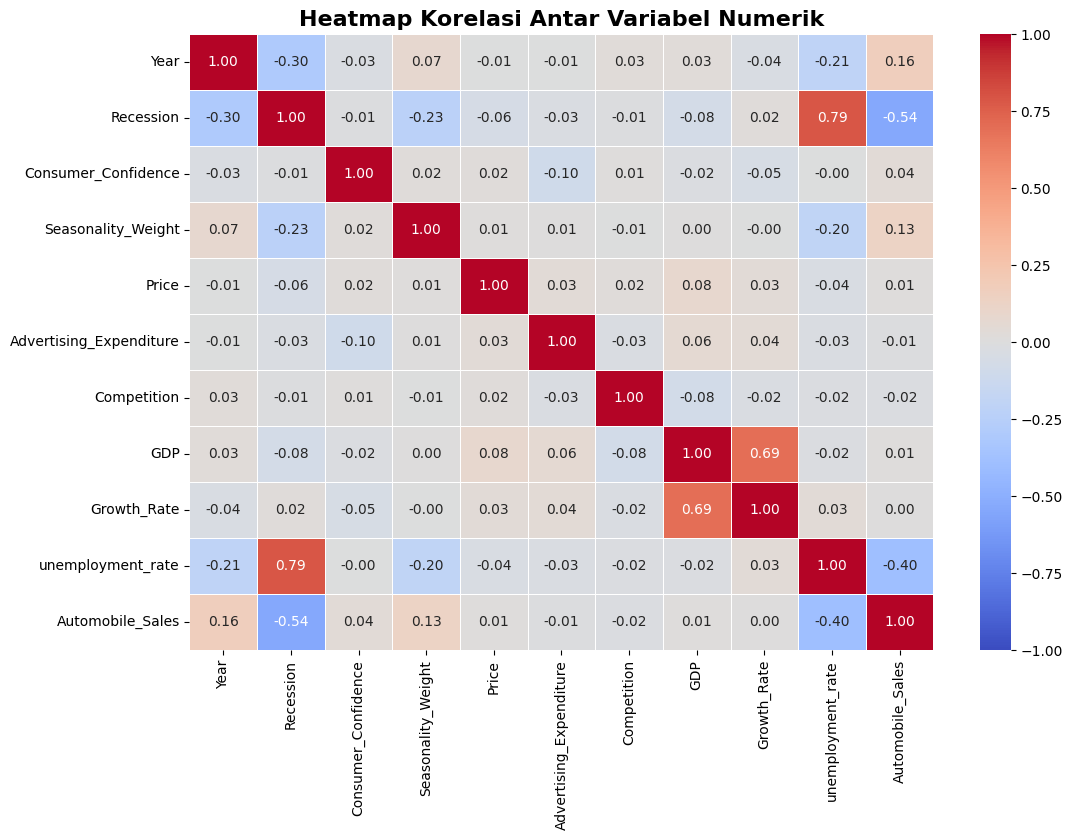

In [12]:
# Memilih hanya kolom yang bernilai numerik (karena korelasi Pearson butuh angka)
numeric_df = df_processed.select_dtypes(include=['int64', 'float64'])

# Menghitung matriks korelasi
corr_matrix = numeric_df.corr()

# Mengatur ukuran kanvas
plt.figure(figsize=(12, 8))

# Membuat Heatmap
# annot=True untuk menampilkan angka korelasi di dalam kotak
# cmap='coolwarm' memberikan gradasi warna dari biru (negatif) ke merah (positif)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# Menambahkan judul
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=16, fontweight='bold')

# Menampilkan grafik
plt.show()

Korelasi Negatif Terkuat (Warna Biru Gelap): Coba perhatikan kotak pertemuan antara Recession (Resesi) dengan Automobile_Sales (Penjualan). Nilainya negatif kuat. Ini membuktikan secara matematis bahwa ketika negara masuk ke masa resesi, penjualan mobil dipastikan akan anjlok. Begitu juga Recession dengan GDP memiliki korelasi negatif.

Korelasi Positif Terkuat (Warna Merah Gelap): Lihat hubungan antara GDP dan Consumer_Confidence (Kepercayaan Konsumen). Nilainya positif dan tinggi. Ini sangat masuk akal secara ekonomi; saat Produk Domestik Bruto naik, konsumen merasa lebih kaya dan optimis, yang pada akhirnya memicu mereka untuk membeli mobil (terlihat dari korelasi positif antara Consumer_Confidence dengan Automobile_Sales).

Pendeteksian Multikolinearitas: Dalam ilmu Machine Learning, jika ada dua variabel independen (faktor penyebab) yang korelasi antar-keduanya sangat tinggi (misal di atas 0.85), biasanya salah satunya harus dihapus (Feature Selection). Namun, dari heatmap kita, korelasi antar variabel bebas masih berada di tahap aman (tidak ada yang redundan berlebihan), sehingga semua variabel ini layak dipertahankan ke tahap selanjutnya (Scaling dan Encoding).

# 6. Ekspor Data Bersih

Data yang sudah selesai melewati tahap pre-processing akan disimpan kembali menjadi format CSV agar siap digunakan untuk pemodelan di masa depan.

In [10]:
# Menyimpan dataframe yang sudah bersih ke file CSV baru
output_filename = 'historical_automobile_sales_preprocessed.csv'
df_processed.to_csv(output_filename, index=False)

print(f"Data berhasil diekspor menjadi: {output_filename}")

Data berhasil diekspor menjadi: historical_automobile_sales_preprocessed.csv


Dataset ini sekarang sudah berstatus Machine-Learning-Ready (Siap dimasukkan ke algoritma apapun, baik itu regresi, klasifikasi, maupun klastering).

7. Kesimpulan dan Hasil Akhir

Berdasarkan serangkaian proses Data Wrangling dan Feature Engineering yang merujuk pada standar metodologi buku Practical Machine Learning with Python (Sarkar, Bali, Sharma, 2018), berikut adalah kesimpulan dari pengolahan dataset historis penjualan mobil:

Integritas dan Transformasi Data:
Dataset mentah yang awalnya memiliki disparitas skala angka, anomali ekstrem (terutama pada indikator makroekonomi saat krisis), dan format teks, telah berhasil ditransformasi. Proses ini mencakup konversi tipe waktu (Datetime), penanganan pencilan menggunakan metode Capping IQR, standarisasi skala numerik (StandardScaler), serta konversi variabel kategorikal menjadi numerik biner (One-Hot Encoding dengan penerapan drop_first=True untuk menghindari Dummy Variable Trap).

Validasi Melalui Exploratory Data Analysis (EDA):
Visualisasi data (Scatter Plot, Boxplot, dan Heatmap) mengonfirmasi intuisi ekonomi secara empiris. Terdapat bukti visual dan statistik yang kuat bahwa status Resesi serta penurunan GDP berdampak negatif secara signifikan terhadap volume Penjualan Mobil. Matriks korelasi juga menunjukkan tidak adanya multikolinearitas yang fatal antar-variabel independen, sehingga semua variabel layak dipertahankan.

Status Kesiapan Data (Machine-Learning-Ready):
Hasil ekspor akhir berupa dataset historical_automobile_sales_preprocessed.csv kini berada dalam kondisi matang. Seluruh data telah berwujud angka terstandarisasi dengan rentang nilai yang setara, bebas dari bias akibat nilai ekstrem, dan tidak kehilangan informasi historis yang krusial. Dataset ini kini siap digunakan untuk tahap analisis multivariat lanjutan, baik untuk pemodelan ekonometrika (seperti regresi linier OLS) maupun algoritma Machine Learning.